Epoch 1/50


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1944/1944 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step - loss: 0.1516 - mae: 0.1516 - val_loss: 0.0536 - val_mae: 0.0536
Epoch 2/50
1944/1944 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - loss: 0.0581 - mae: 0.0581 - val_loss: 0.0489 - val_mae: 0.0489
Epoch 3/50
1944/1944 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step - loss: 0.0534 - mae: 0.0534 - val_loss: 0.0448 - val_mae: 0.0448
Epoch 4/50
1944/1944 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - loss: 0.0510 - mae: 0.0510 - val_loss: 0.0436 - val_mae: 0.0436
Epoch 5/50
1944/1944 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - loss: 0.0497 - mae: 0.0497 - val_loss: 0.0451 - val_mae: 0.0451
Epoch 6/50
1944/1944 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - loss: 0.0494 - mae: 0.0494 - val_loss: 0.0439 - val_mae: 0.0439
Epoch 7/50
1944/1944 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - loss: 0.0489 - mae: 0.0489 - val_loss: 0.0412 - val_mae: 0.0412
Epoch 8/50
1944/1944 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - loss: 0.0490 - mae: 0.0490 - val_loss: 0.0417 - val_mae: 0.0417
Epoch 9/50
1944/1944 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/st

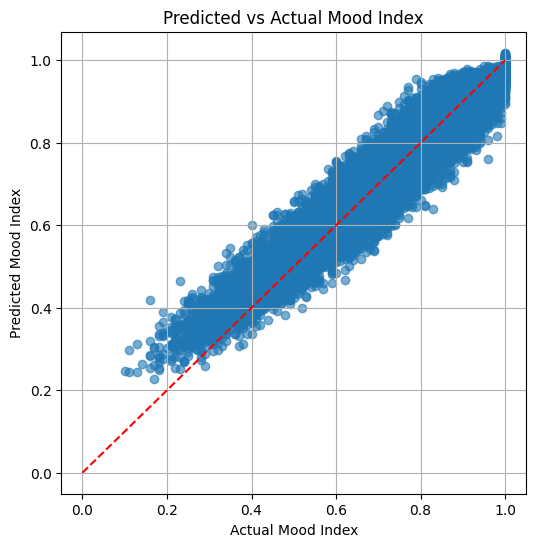

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

# Load and prep
dataset = pd.read_csv("data1.csv")

# Define features and target (regression)
X = dataset.drop(columns=["mood_index"])
y = dataset["mood_index"]
dataset['mood_index'].value_counts()

# One-hot encode if needed
X = pd.get_dummies(X, drop_first=True)

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)

# Standardize features
sc = StandardScaler()
X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)

# Build ANN for regression
model = Sequential()
model.add(Dense(64, activation='relu', input_dim=X_train.shape[1]))
model.add(Dropout(0.3))
model.add(Dense(32, activation='relu'))
model.add(Dropout(0.2))
model.add(Dense(1, activation='linear'))  # Output: one real-valued number

# Compile
model.compile(optimizer='adam', loss='mean_absolute_error', metrics=['mae'])

# Train
history = model.fit(X_train, y_train, batch_size=32, epochs=50, validation_split=0.1, verbose=1)

# Predict
y_pred = model.predict(X_test)

# Evaluate
print("MAE:", mean_absolute_error(y_test, y_pred))
print("MSE:", mean_squared_error(y_test, y_pred))
print("R² score:", r2_score(y_test, y_pred))

# Plot predictions vs actual
plt.figure(figsize=(6, 6))
plt.scatter(y_test, y_pred, alpha=0.6)
plt.plot([0, 1], [0, 1], '--', color='red')
plt.xlabel("Actual Mood Index")
plt.ylabel("Predicted Mood Index")
plt.title("Predicted vs Actual Mood Index")
plt.grid(True)
plt.show()
